he and glorot initialization designed to make std of input approximatly equal to the std of output,if we initilazed the nodes with the same value its like we have one node per layer so its not recomended,its okay to initialize the bias with zero or any other value 

In [2]:
import torch
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])
train_and_valid_set = torchvision.datasets.CIFAR10(
    root="datasets", train=True, download=True, transform=toTensor)
test_set = torchvision.datasets.CIFAR10(
    root="datasets", train=False, download=True, transform=toTensor)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s] 


In [5]:
torch.manual_seed(42)
train_set, valid_set = torch.utils.data.random_split(
train_and_valid_set, [45_000, 5_000])

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=128,shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=128)
test_loader = DataLoader(test_set, batch_size=128)

In [13]:
train_loader.dataset[0][0].shape, train_loader.dataset[0][1]

(torch.Size([3, 32, 32]), 6)

In [17]:
train_loader.dataset[0][0]

Image([[[0.2392, 0.2784, 0.3059,  ..., 0.3059, 0.2784, 0.2275],
        [0.4471, 0.4275, 0.3647,  ..., 0.3216, 0.2784, 0.2353],
        [0.3137, 0.2588, 0.1922,  ..., 0.3686, 0.3608, 0.3176],
        ...,
        [0.0157, 0.0235, 0.0000,  ..., 0.4431, 0.4078, 0.4431],
        [0.0314, 0.0549, 0.0235,  ..., 0.4627, 0.3804, 0.3529],
        [0.1490, 0.1490, 0.1137,  ..., 0.3765, 0.3294, 0.3569]],

       [[0.2235, 0.2431, 0.2745,  ..., 0.2549, 0.2275, 0.1843],
        [0.4275, 0.3922, 0.3412,  ..., 0.2863, 0.2392, 0.2000],
        [0.2980, 0.2353, 0.1922,  ..., 0.3451, 0.3255, 0.2824],
        ...,
        [0.0706, 0.0510, 0.0706,  ..., 0.2980, 0.2196, 0.1922],
        [0.0471, 0.0588, 0.0510,  ..., 0.3020, 0.2314, 0.1765],
        [0.1137, 0.0980, 0.0706,  ..., 0.2000, 0.1647, 0.1922]],

       [[0.2196, 0.2353, 0.2588,  ..., 0.2000, 0.1882, 0.1490],
        [0.4392, 0.4118, 0.3412,  ..., 0.2235, 0.1961, 0.1686],
        [0.2745, 0.2118, 0.1333,  ..., 0.2941, 0.2902, 0.2588],
        ..

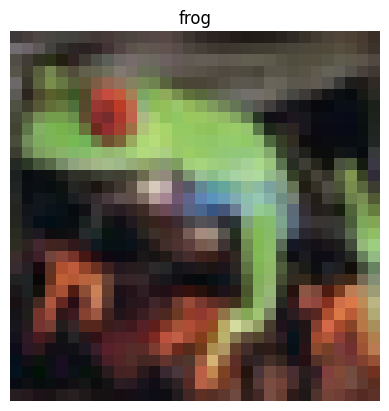

In [19]:
import matplotlib.pyplot as plt
def show_image(image, label):
    plt.imshow(image.permute(1, 2, 0))
    plt.title(label)
    plt.axis("off")
    plt.show()
class_names = train_and_valid_set.classes
image, label = train_loader.dataset[0]
show_image(image, class_names[label])

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [20]:
from torch import nn

In [21]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [23]:
def build_deep_model(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons), nn.SiLU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SiLU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [24]:
torch.manual_seed(42)
model = build_deep_model(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [26]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 40.3 MB/s eta 0:00:00


In [28]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

In [29]:
import time

def train_with_early_stopping(model, optimizer, loss_fn, metric, train_loader,
                              valid_loader, n_epochs, patience=10,
                              checkpoint_path=None, scheduler=None):
    checkpoint_path = checkpoint_path or "my_checkpoint.pt"
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    best_metric = 0.0
    patience_counter = 0
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        t0 = time.time()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)

        train_metric = metric.compute().item()
        valid_metric = evaluate_tm(model, valid_loader, metric).item()
        if valid_metric > best_metric:
            torch.save(model.state_dict(), checkpoint_path)
            best_metric = valid_metric
            best = " (best)"
            patience_counter = 0
        else:
            patience_counter += 1
            best = ""

        t1 = time.time()
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(train_metric)
        history["valid_metrics"].append(valid_metric)
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}{best}"
              f" in {t1 - t0:.1f}s"
        )
        if scheduler is not None:
            scheduler.step()
        if patience_counter >= patience:
            print("Early stopping!")
            break

    model.load_state_dict(torch.load(checkpoint_path))
    return history

In [30]:
optimizer = torch.optim.NAdam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [31]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

Epoch 1/100, train loss: 2.1165, train metric: 0.1828, valid metric: 0.1900 (best) in 21.2s
Epoch 2/100, train loss: 1.9705, train metric: 0.2477, valid metric: 0.2594 (best) in 20.8s
Epoch 3/100, train loss: 1.8962, train metric: 0.2831, valid metric: 0.2454 in 21.8s
Epoch 4/100, train loss: 1.8724, train metric: 0.2951, valid metric: 0.2956 (best) in 20.9s
Epoch 5/100, train loss: 1.8800, train metric: 0.2915, valid metric: 0.2892 in 20.9s
Epoch 6/100, train loss: 1.8530, train metric: 0.3045, valid metric: 0.2950 in 20.2s
Epoch 7/100, train loss: 1.8610, train metric: 0.2986, valid metric: 0.2892 in 20.4s
Epoch 8/100, train loss: 1.8539, train metric: 0.2965, valid metric: 0.2826 in 20.9s
Epoch 9/100, train loss: 1.8429, train metric: 0.3030, valid metric: 0.3148 (best) in 20.1s
Epoch 10/100, train loss: 1.8000, train metric: 0.3203, valid metric: 0.3140 in 20.9s
Epoch 11/100, train loss: 1.7795, train metric: 0.3358, valid metric: 0.3420 (best) in 20.1s
Epoch 12/100, train loss: 1.

In [ ]:
def build_deep_model_with_batch_norm(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), nn.Linear(n_inputs, n_neurons),
              nn.BatchNorm1d(n_neurons), nn.SiLU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons),
                   nn.BatchNorm1d(n_neurons), nn.SiLU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_he_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_batch_norm(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [ ]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

In [ ]:
class Standardize(nn.Module):
    def __init__(self, sample):
        super().__init__()
        flat = torch.flatten(sample, start_dim=1)
        mean = flat.mean(dim=0, keepdim=True)
        std = flat.std(dim=0, keepdim=True)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std

In [ ]:
all_images = torch.stack([img for img, _ in train_set])
standardize = Standardize(all_images)

In [ ]:
def use_lecun_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight, mode="fan_in",
                                nonlinearity="linear")
        nn.init.zeros_(module.bias)

In [ ]:
def build_deep_model_with_selu(n_hidden, n_neurons, n_inputs, n_outputs):
    layers = [nn.Flatten(), standardize,
              nn.Linear(n_inputs, n_neurons), nn.SELU()]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SELU()]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_lecun_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_selu(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10
).to(device)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
n_epochs = 100
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs)

try 1cycle schecudling

In [ ]:
def build_deep_model_with_alpha_dropout(n_hidden, n_neurons, n_inputs,
                                        n_outputs, dropout_rate):
    layers = [nn.Flatten(), standardize,
              nn.Linear(n_inputs, n_neurons), nn.SELU(),
              nn.AlphaDropout(dropout_rate)]
    for _ in range(n_hidden - 1):
        layers += [nn.Linear(n_neurons, n_neurons), nn.SELU(),
                   nn.AlphaDropout(dropout_rate)]

    layers += [nn.Linear(n_neurons, n_outputs)]
    model = torch.nn.Sequential(*layers)
    model.apply(use_lecun_init)
    return model

In [ ]:
torch.manual_seed(42)
model = build_deep_model_with_alpha_dropout(
    n_hidden=20, n_neurons=100, n_inputs=3 * 32 * 32, n_outputs=10,
    dropout_rate=0.1
).to(device)

In [ ]:
n_epochs = 60
optimizer = torch.optim.NAdam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, epochs=n_epochs, steps_per_epoch=len(train_loader), max_lr=1e-2)
criterion = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

In [ ]:
history = train_with_early_stopping(model, optimizer, criterion, accuracy,
                                    train_loader, valid_loader, n_epochs,
                                    patience=20, scheduler=scheduler)